# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [2]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

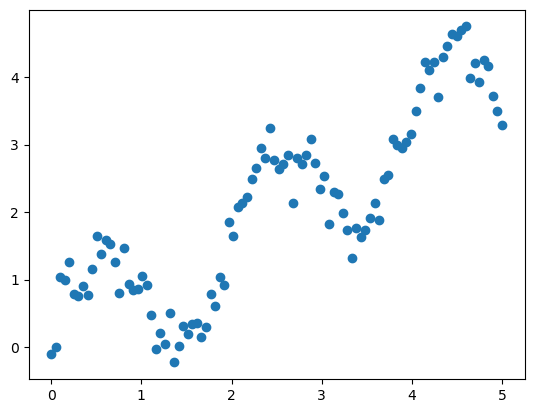

In [3]:
plt.scatter(x,y)

#### nonlinear

In [4]:
regr_lin = LinearRegression()

In [5]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [6]:
regr_lin.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


0.5226769838778449


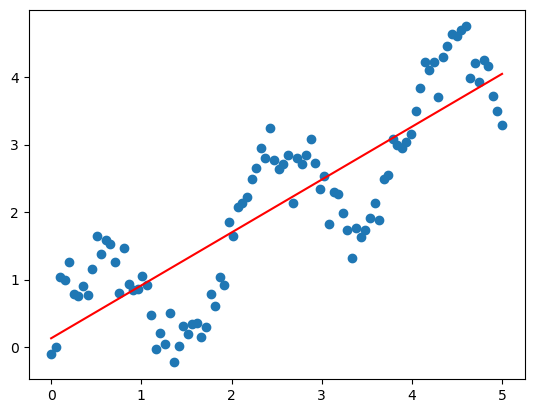

In [7]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [8]:
print(x.shape)

(100,)


In [9]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape)

(100, 5)


In [10]:
regr_poly = LinearRegression()

In [11]:
regr_poly.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


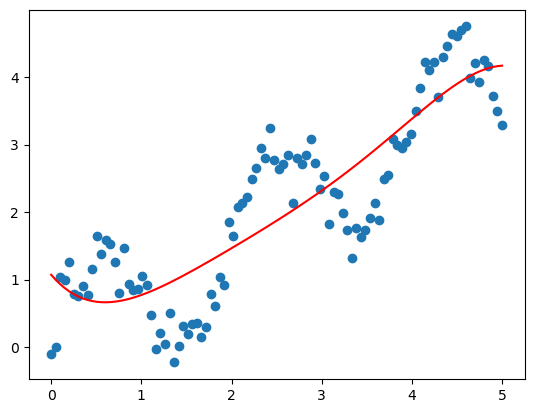

In [12]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')

In [13]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-1.57844835  1.90871043 -0.77351829  0.15506761 -0.01182659]
interception:  1.0722358759648887


In [15]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b

array([1.07223588, 0.99728628, 0.93149012, 0.87428524, 0.82513276,
       0.78351662, 0.74894311, 0.72094039, 0.69905806, 0.68286664,
       0.67195716, 0.66594066, 0.66444772, 0.66712801, 0.67364982,
       0.6836996 , 0.69698147, 0.71321677, 0.73214361, 0.75351636,
       0.77710524, 0.80269579, 0.83008848, 0.85909815, 0.88955364,
       0.92129725, 0.95418431, 0.98808271, 1.02287242, 1.05844504,
       1.09470333, 1.13156072, 1.16894089, 1.20677727, 1.24501256,
       1.28359831, 1.32249443, 1.36166869, 1.40109632, 1.44075949,
       1.48064687, 1.52075316, 1.56107861, 1.60162858, 1.64241303,
       1.68344611, 1.72474564, 1.7663327 , 1.8082311 , 1.85046696,
       1.89306823, 1.93606422, 1.97948514, 2.02336163, 2.06772428,
       2.11260321, 2.15802753, 2.20402494, 2.25062124, 2.29783986,
       2.34570138, 2.39422311, 2.44341855, 2.49329701, 2.54386307,
       2.59511616, 2.64705008, 2.69965252, 2.75290461, 2.80678044,
       2.86124663, 2.9162618 , 2.97177616, 3.02773102, 3.08405

In [16]:
regr_poly.predict(X_poly)

array([1.07223588, 0.99728628, 0.93149012, 0.87428524, 0.82513276,
       0.78351662, 0.74894311, 0.72094039, 0.69905806, 0.68286664,
       0.67195716, 0.66594066, 0.66444772, 0.66712801, 0.67364982,
       0.6836996 , 0.69698147, 0.71321677, 0.73214361, 0.75351636,
       0.77710524, 0.80269579, 0.83008848, 0.85909815, 0.88955364,
       0.92129725, 0.95418431, 0.98808271, 1.02287242, 1.05844504,
       1.09470333, 1.13156072, 1.16894089, 1.20677727, 1.24501256,
       1.28359831, 1.32249443, 1.36166869, 1.40109632, 1.44075949,
       1.48064687, 1.52075316, 1.56107861, 1.60162858, 1.64241303,
       1.68344611, 1.72474564, 1.7663327 , 1.8082311 , 1.85046696,
       1.89306823, 1.93606422, 1.97948514, 2.02336163, 2.06772428,
       2.11260321, 2.15802753, 2.20402494, 2.25062124, 2.29783986,
       2.34570138, 2.39422311, 2.44341855, 2.49329701, 2.54386307,
       2.59511616, 2.64705008, 2.69965252, 2.75290461, 2.80678044,
       2.86124663, 2.9162618 , 2.97177616, 3.02773102, 3.08405

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [17]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [18]:
sigma = 0.3

In [19]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [20]:
regr_rbf = LinearRegression()

In [21]:
regr_rbf.fit(X_rbf, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


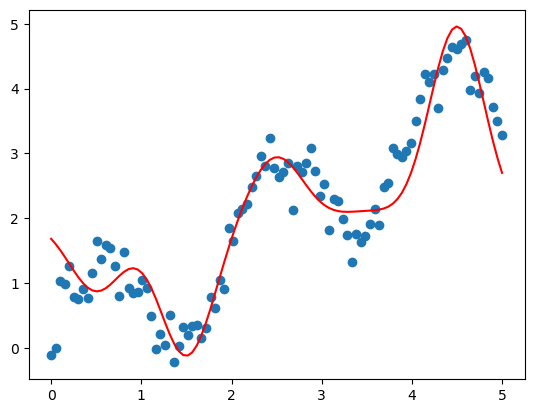

In [22]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [23]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-1.06878199 -2.0715525   1.00102852  0.15030732  3.01025874]
interception:  1.9482396162474491


#### Comparison

In [24]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

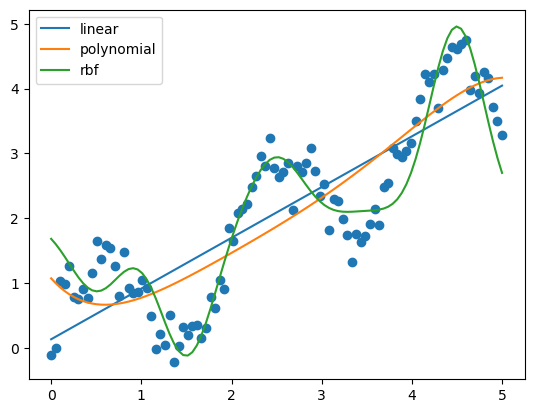

In [25]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()

## 請計算模型的MSE

In [26]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.5226769838778449


In [27]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.46070172580796287


In [28]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.20824945954583274
